# Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import FactorAnalysis
import pingouin as pg
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Load Data (Internet Required)

In [2]:
df = pd.read_csv("https://docs.google.com/spreadsheets/d/1Dmy11XxB85wDM37S5MTCdGrlQ4zmzmTHGIcwUIj0eyU/export?format=csv")
print(f"Jumlah Responden: {df.shape[0]}")

Jumlah Responden: 67


# Handle Invalid Respondent Input

# Rename Columns

In [3]:
df = df.rename(columns={'Kelas \n(Kelas LAB / Survey Sampling and Methodology)' : 'Kelas'})

In [4]:
new_columns_var_y = {
    old: f"Y{i+1}"
    for i, old in enumerate(df.columns[3:23])
}

In [5]:
df = df.rename(columns=new_columns_var_y)

In [6]:
df.iloc[:, 0:5].head()

,Timestamp,Kelas,Gender,Y1,Y2
0,5/13/2026 17:29:21,LC09,Pria,2,5
1,5/13/2026 18:16:32,LA09,Wanita,2,2
2,5/13/2026 19:23:32,LB09,Pria,3,2
3,5/13/2026 19:31:11,LB09,Pria,2,3
4,5/13/2026 21:07:03,LB09,Wanita,1,1


In [7]:
df.iloc[:, 20:25].head()

,Y18,Y19,Y20,"Selama periode Mid Exam (Semester 4), saya yakin mampu menyelesaikan tugas atau soal yang sulit jika saya berusaha dengan sungguh-sungguh.","Selama periode Mid Exam (Semester 4), ketika menghadapi hambatan dari orang lain, saya mampu menemukan jalan tengah dan cara untuk mencapai tujuan akademik saya\n(misal: keluarga, teman, atau orang lainnya)"
0,4,3,5,3,3
1,4,5,5,3,2
2,3,3,2,4,3
3,3,4,3,3,3
4,4,4,1,3,3


In [8]:
new_columns_var_x = {
    old: f"X{i+1}"
    for i, old in enumerate(df.columns[23:33])
}

In [9]:
df = df.rename(columns=new_columns_var_x)

In [10]:
df.iloc[:, 20:25].head()

,Y18,Y19,Y20,X1,X2
0,4,3,5,3,3
1,4,5,5,3,2
2,3,3,2,4,3
3,3,4,3,3,3
4,4,4,1,3,3


In [11]:
df.iloc[:, 28:33].head()

,X6,X7,X8,X9,X10
0,3,2,3,2,2
1,3,2,2,2,2
2,4,3,3,3,2
3,4,3,4,3,4
4,3,3,3,3,3


# Split DataFrame
Variable Y for Clustering = Target<br>
VAriable X + 'Gender' + 'Kelas' + 'label' for Classification

In [12]:
timestamps = [
    '5/23/2026 12:30:10',
    '5/23/2026 12:31:58'
]

df.loc[
    df['Timestamp'].isin(timestamps),
    'Kelas'
] = 'LD09'

df[df['Timestamp'].isin(timestamps)] 

,Timestamp,Kelas,Gender,Y1,Y2,Y3,Y4,Y5,Y6,Y7,...,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
55,5/23/2026 12:30:10,LD09,Pria,2,2,5,5,4,2,5,...,3,3,3,3,3,3,3,3,3,3
56,5/23/2026 12:31:58,LD09,Pria,2,4,2,2,2,2,4,...,4,4,3,4,4,4,3,4,4,4


In [13]:
var_y = df.iloc[:, 3:23]

In [14]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


In [15]:
var_x = df.iloc[:, 23:33]

In [16]:
var_x.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,3,3,2,2,3,3,2,3,2,2
1,3,2,2,2,2,3,2,2,2,2
2,4,3,3,2,2,4,3,3,3,2
3,3,3,3,2,3,4,3,4,3,4
4,3,3,2,2,3,3,3,3,3,3


# Variable Setup

## Variable Y

In [17]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


Sub Skala Dari Indikator Variabel Y (ASI | Academic Stress Inventory)
- Faktor 2 (Result Stress) : 1 - 5
- Faktor 3 (Tests Stress) : 6 - 9
- Faktor 5 (Peer Stress) : 10 - 13
- Faktor 6 (Time Management Stress) : 14 - 16
- Faktor 7 (Self-Inflicted Stress) : 17 - 20

In [18]:
subscale_items_y = {
    "Faktor 2": [i for i in var_y.columns[:5]],
    "Faktor 3": [i for i in var_y.columns[5:9]],
    "Faktor 5": [i for i in var_y.columns[9:13]],
    "Faktor 6": [i for i in var_y.columns[13:16]],
    "Faktor 7": [i for i in var_y.columns[16:]]
}

In [19]:
subscale_items_y

{'Faktor 2': ['Y1', 'Y2', 'Y3', 'Y4', 'Y5'],
 'Faktor 3': ['Y6', 'Y7', 'Y8', 'Y9'],
 'Faktor 5': ['Y10', 'Y11', 'Y12', 'Y13'],
 'Faktor 6': ['Y14', 'Y15', 'Y16'],
 'Faktor 7': ['Y17', 'Y18', 'Y19', 'Y20']}

## Variable X

In [20]:
var_x.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,3,3,2,2,3,3,2,3,2,2
1,3,2,2,2,2,3,2,2,2,2
2,4,3,3,2,2,4,3,3,3,2
3,3,3,3,2,3,4,3,4,3,4
4,3,3,2,2,3,3,3,3,3,3


In [21]:
items_x = [i for i in var_x.columns]

# Measurement Quality
- Validity
- Reliability
- Response Bias

## Validity

### a. Corrected Item-Total Correlation

In [22]:
def get_r_table(n, alpha = 0.05):
    t_dis = stats.t.ppf(1 - alpha/2, df = n - 2)
    return t_dis / np.sqrt(t_dis**2 + (n - 2))

def item_total_check(df, items, label):
    print('='*50)
    print(f" {label}")
    print('='*50)
    print(f"{'item':<12} {'r':>6} {'p':>6} {'status'}")
    
    n = len(df)
    r_tabel = get_r_table(n)
    
    total = df[items].sum(axis = 1)
    valid_count = 0
    
    for item in items:
        corrected_total = total - df[item] # corrected -> dikurangi nilai nya sendiri
        r, p = stats.pearsonr(df[item], corrected_total)
        # status = "Valid" if r >= 0.3 else "Not Valid"
        status = "Valid" if r >= r_tabel else "Not Valid"
        
        if status == "Valid":
            valid_count += 1
        print(f"{item:<12} {r:>6.3f} {p:>6.3f} {status}")
    
    print("\nValid:", valid_count, "/", len(items), "items")

In [23]:
for name, items in subscale_items_y.items():
    item_total_check(var_y, items, f"Y - {name}")

 Y - Faktor 2
item              r      p status
Y1            0.589  0.000 Valid
Y2            0.437  0.000 Valid
Y3            0.482  0.000 Valid
Y4            0.643  0.000 Valid
Y5            0.545  0.000 Valid

Valid: 5 / 5 items
 Y - Faktor 3
item              r      p status
Y6            0.566  0.000 Valid
Y7            0.294  0.016 Valid
Y8            0.492  0.000 Valid
Y9            0.264  0.031 Valid

Valid: 4 / 4 items
 Y - Faktor 5
item              r      p status
Y10           0.462  0.000 Valid
Y11           0.531  0.000 Valid
Y12           0.323  0.008 Valid
Y13           0.456  0.000 Valid

Valid: 4 / 4 items
 Y - Faktor 6
item              r      p status
Y14           0.737  0.000 Valid
Y15           0.759  0.000 Valid
Y16           0.351  0.004 Valid

Valid: 3 / 3 items
 Y - Faktor 7
item              r      p status
Y17           0.749  0.000 Valid
Y18           0.461  0.000 Valid
Y19           0.300  0.014 Valid
Y20           0.527  0.000 Valid

Valid: 4 / 4 items


In [24]:
item_total_check(var_x, items_x, "X")

 X
item              r      p status
X1            0.520  0.000 Valid
X2            0.451  0.000 Valid
X3            0.691  0.000 Valid
X4            0.596  0.000 Valid
X5            0.523  0.000 Valid
X6            0.472  0.000 Valid
X7            0.601  0.000 Valid
X8            0.743  0.000 Valid
X9            0.723  0.000 Valid
X10           0.705  0.000 Valid

Valid: 10 / 10 items


### b. Construct Validity | Exploratory Factor Analysis (EFA)
opsional dari indikator yang dipakai dari variabel Y sudah ada pembagian faktor dan EFA disini hanya untuk mengukur apakah ada faktor-faktor yang berkaitan (opsional / hanya untuk interpretasi indikator)

In [25]:
# ── 1. Uji Kelayakan EFA ──────────────────────────────────────
# Bartlett's Test: data harus signifikan (p < 0.05)
chi2, p = calculate_bartlett_sphericity(var_y)
print(f"Bartlett's Test: chi2 = {chi2:.3f}, p = {p:.3f}")
print("✅ Layak" if p < 0.05 else "❌ Tidak layak untuk EFA")

# KMO: ukur kecukupan sampling (harus > 0.50, idealnya > 0.60)
kmo_all, kmo_model = calculate_kmo(var_y)
print(f"\nKMO Score: {kmo_model:.3f}")
if kmo_model >= 0.80:
    print("✅ Meritorious")
elif kmo_model >= 0.70:
    print("✅ Middling")
elif kmo_model >= 0.60:
    print("✅ Mediocre tapi masih acceptable")
else:
    print("❌ Tidak layak")

Bartlett's Test: chi2 = 599.716, p = 0.000
✅ Layak

KMO Score: 0.739
✅ Middling


In [26]:
# ── 2. EFA dengan 5 faktor (sesuai struktur ASI) ─────────────
fa = FactorAnalyzer(n_factors=5, rotation="oblimin")
# oblimin karena sub-skala stress kemungkinan saling berkorelasi
# kalau mau asumsikan tidak berkorelasi, ganti ke "varimax"
fa.fit(var_y)

FactorAnalyzer(n_factors=5, rotation='oblimin', rotation_kwargs={})

In [27]:
# ── 3. Factor Loadings ────────────────────────────────────────
loadings = pd.DataFrame(
    fa.loadings_,
    index=var_y.columns,
    columns=[f"F{i+1}" for i in range(5)]
)

print("\n=== Factor Loadings ===")
print(loadings.round(3).to_string())
print("\nItem dengan loading ≥ 0.40 dianggap valid secara konstruk")

# Tampilkan item mana yang dominan di faktor mana
print("\n=== Dominant Factor per Item ===")
for item in loadings.index:
    dominant = loadings.loc[item].abs().idxmax()
    val = loadings.loc[item, dominant]
    status = "✅" if abs(val) >= 0.40 else "⚠️ loading lemah"
    print(f"{item}: {dominant} (loading = {val:.3f}) {status}")


=== Factor Loadings ===
        F1     F2     F3     F4     F5
Y1   0.030  0.005  0.773 -0.076  0.060
Y2   0.109  0.126  0.479 -0.004 -0.023
Y3   0.524 -0.117  0.272 -0.136  0.002
Y4   0.456  0.102  0.332  0.206  0.131
Y5   0.436 -0.047  0.242  0.108  0.237
Y6  -0.044  0.247 -0.058  0.081  0.666
Y7  -0.240  0.048 -0.243  0.160  0.516
Y8   0.137 -0.125  0.137 -0.091  0.738
Y9   0.408 -0.092  0.079  0.453  0.156
Y10 -0.197  0.118  0.133  0.521  0.250
Y11  0.029  0.009 -0.081  0.809 -0.059
Y12 -0.021  0.002  0.458  0.212 -0.041
Y13  0.431  0.134  0.033  0.460  0.059
Y14  0.065  0.875  0.015  0.048 -0.096
Y15 -0.007  0.985  0.008 -0.038  0.076
Y16 -0.323  0.271  0.445  0.204 -0.097
Y17  0.887  0.067  0.035  0.053  0.010
Y18  0.451  0.228 -0.094 -0.245  0.225
Y19  0.500  0.071 -0.242 -0.009 -0.072
Y20  0.480  0.101  0.475 -0.078  0.033

Item dengan loading ≥ 0.40 dianggap valid secara konstruk

=== Dominant Factor per Item ===
Y1: F3 (loading = 0.773) ✅
Y2: F3 (loading = 0.479) ✅
Y3: F1 (l

In [28]:
# ── 4. Variance Explained ─────────────────────────────────────
ss_loadings, variance, cumulative = fa.get_factor_variance()

var_df = pd.DataFrame({
    "SS Loadings":    ss_loadings,
    "Variance (%)":   variance * 100,
    "Cumulative (%)": cumulative * 100
}, index=[f"F{i+1}" for i in range(5)])

print("\n=== Variance Explained ===")
print(var_df.round(3).to_string())


=== Variance Explained ===
    SS Loadings  Variance (%)  Cumulative (%)
F1        2.736        13.682          13.682
F2        2.043        10.216          23.898
F3        1.885         9.425          33.323
F4        1.619         8.097          41.420
F5        1.507         7.536          48.956


## Reliability

Kriteria Alpha per sub-skala:

| Alpha | Interpretasi |
|---|---|
| ≥ 0.90 | Excellent |
| 0.80 – 0.89 | Good |
| 0.70 – 0.79 | Acceptable |
| 0.60 – 0.69 | Questionable |
| < 0.60 | Poor |

In [29]:
def cronbach_alpha(df, items):
    subset = df[items]
    k = len(items)
    var_items = subset.var(axis=0, ddof=1).sum() # total dari variance item indikator / soal indikator
    var_res = subset.sum(axis=1).var(ddof=1) # variance dari total jawaban responden 1 dengan responden lainnya
    return (k / (k - 1)) * (1 - var_items / var_res)

def interpret_alpha(a):
    if a >= 0.90: return "Excellent"
    if a >= 0.80: return "Good"
    if a >= 0.70: return "Acceptable"
    if a >= 0.60: return "Questionable"
    return "Poor"

In [30]:
print("=== Cronbach's Alpha per Sub-Skala Y ===\n")
print(f"{'Sub-Skala':<35} {'Alpha':>6}  {'Interpretasi'}")
print("-" * 60)

for nama, items in subscale_items_y.items():
    a = cronbach_alpha(var_y, items)
    print(f"{nama:<35} {a:>6.3f}  {interpret_alpha(a)}")

=== Cronbach's Alpha per Sub-Skala Y ===

Sub-Skala                            Alpha  Interpretasi
------------------------------------------------------------
Faktor 2                             0.765  Acceptable
Faktor 3                             0.620  Questionable
Faktor 5                             0.661  Questionable
Faktor 6                             0.766  Acceptable
Faktor 7                             0.714  Acceptable


In [31]:
print("\n=== Cronbach's Alpha X ===\n")
a_x = cronbach_alpha(var_x, items_x)
print("-" * 60)
print(f"{'X':<35} {a_x:>6.3f}  {interpret_alpha(a_x)}")
print("-" * 60)


=== Cronbach's Alpha X ===

------------------------------------------------------------
X                                    0.876  Good
------------------------------------------------------------


## Response Bias

**1. Acquiescence Bias**
- Hitung rata-rata jawaban per responden
- Flagging kalau mean ≥ 4 secara konsisten
- Plot: histogram distribusi mean per responden

**2. Extreme Response Bias**
- Hitung proporsi jawaban 1 atau 5 per responden
- Flagging kalau > 40% jawabannya ekstrem
- Plot: histogram proporsi ekstrem per responden

**3. Straight-lining**
- Hitung variance jawaban per responden
- Flagging kalau variance = 0 (semua jawaban sama persis)
- Plot: tidak perlu, cukup list siapa saja yang straight-liner

---

Laporannya biasanya berbentuk:

> *"Dari 100 responden, ditemukan 3 straight-liner dan 8 responden dengan extreme response rate > 40%, sehingga dieksklusi dari analisis."*

Responden yang ter-flag **bisa dieksklusi** sebelum lanjut ke analisis utama, tapi keputusan eksklusi harus dicatat dan dijelaskan.

---


### a. Acquiescence Bias

In [32]:
y_mean = var_y.mean(axis = 1) / 5
y_high_acq = y_mean >= 0.8
y_low_acq = y_mean <= 0.2
y_acq_flag = y_high_acq | y_low_acq
y_acq_flag.value_counts()

False    62
True      5
Name: count, dtype: int64

In [33]:
x_mean = var_x.mean(axis = 1) / 4
x_high_acq = x_mean >= 0.85
x_low_acq = x_mean <= 0.15
x_acq_flag = x_high_acq | x_low_acq
x_acq_flag.value_counts()

False    57
True     10
Name: count, dtype: int64

### b. Extreme Response Bias

In [34]:
extreme_y = var_y.apply(lambda r: ((r == 1) | (r == 5)).mean(), axis = 1)
extreme_y_flag = extreme_y > 0.6
extreme_y_flag.value_counts()

False    61
True      6
Name: count, dtype: int64

In [35]:
extreme_y_mid = var_y.apply(lambda r: ((r == 3)).mean(), axis = 1)
extreme_y_mid_flag = extreme_y_mid > 0.6
extreme_y_mid_flag.value_counts()

False    64
True      3
Name: count, dtype: int64

In [36]:
extreme_x = var_x.apply(lambda r: ((r == 1) | (r == 4)).mean(), axis = 1)
extreme_x_flag = extreme_x > 0.4
extreme_x_flag.value_counts()

False    58
True      9
Name: count, dtype: int64

### c. Straight Lining

In [37]:
straight_y = var_y.var(axis = 1) == 0
straight_x = var_x.var(axis = 1) == 0
straight_flag = straight_y | straight_x
straight_flag.value_counts()

False    61
True      6
Name: count, dtype: int64

### Summary

In [38]:
# ── Summary ──────────────────────────────────────────────────
print("=== Response Bias Summary ===\n")
print(f"Total responden              : {len(df)}")
print(f"\n--- Variabel Y (skala 1-5) ---")
print(f"Acquiescence (≥80% max)      : {y_acq_flag.sum()} ({y_acq_flag.mean()*100:.1f}%)")
print(f"Extreme response (>40%)      : {extreme_y_flag.sum()} ({extreme_y_flag.mean()*100:.1f}%)")
print(f"Extreme response mid (>40%)  : {extreme_y_mid_flag.sum()} ({extreme_y_mid_flag.mean()*100:.1f}%)")

print(f"\n--- Variabel X (skala 1-4) ---")
print(f"Acquiescence (≥80% max)      : {x_acq_flag.sum()} ({x_acq_flag.mean()*100:.1f}%)")
print(f"Extreme response (>40%)      : {extreme_x_flag.sum()} ({extreme_x_flag.mean()*100:.1f}%)")

print(f"\n--- Straight-lining ---")
print(f"Y straight-liners            : {straight_y.sum()}")
print(f"X straight-liners            : {straight_x.sum()}")

=== Response Bias Summary ===

Total responden              : 67

--- Variabel Y (skala 1-5) ---
Acquiescence (≥80% max)      : 5 (7.5%)
Extreme response (>40%)      : 6 (9.0%)
Extreme response mid (>40%)  : 3 (4.5%)

--- Variabel X (skala 1-4) ---
Acquiescence (≥80% max)      : 10 (14.9%)
Extreme response (>40%)      : 9 (13.4%)

--- Straight-lining ---
Y straight-liners            : 1
X straight-liners            : 6


- Straight-lining → Perlu drop kaena tidak representatif jawaban responden
- Extreme response → Drop jika dicurigai hanya menjawab nilai extreme saja
- Acquiescence → dipertimbangkan karena bisa saja pola umum responden
- Midpoint → catat sebagai catatan, drop opsional

In [39]:
flagged_y = y_acq_flag | extreme_y_flag | straight_y
print(f"\nTotal ter-flag y             : {flagged_y.sum()} responden")
if flagged_y.sum() > 0:
    print(f"Index responden              : {list(df[flagged_y].index)}")

flagged_x = x_acq_flag | extreme_x_flag | straight_x
print(f"\nTotal ter-flag x             : {flagged_x.sum()} responden")
if flagged_x.sum() > 0:
    print(f"Index responden              : {list(df[flagged_x].index)}")

flagged = flagged_x | flagged_y
print(f"\nTotal ter-flag               : {flagged.sum()} responden")
if flagged.sum() > 0:
    print(f"Index responden              : {list(df[flagged].index)}")


Total ter-flag y             : 10 responden
Index responden              : [0, 5, 20, 21, 26, 32, 34, 43, 61, 66]

Total ter-flag x             : 14 responden
Index responden              : [5, 25, 32, 34, 37, 43, 45, 51, 55, 56, 58, 60, 61, 65]

Total ter-flag               : 19 responden
Index responden              : [0, 5, 20, 21, 25, 26, 32, 34, 37, 43, 45, 51, 55, 56, 58, 60, 61, 65, 66]


In [40]:
bias_summary = pd.DataFrame({
    'acq_y':     y_acq_flag,
    'acq_x':     x_acq_flag,
    'extreme_y': extreme_y_flag,
    'extreme_x': extreme_x_flag,
    'straight_x_or_y': straight_flag,
})

bias_summary['total_bias'] = bias_summary.sum(axis=1)
print(bias_summary[bias_summary['total_bias'] > 0])

    acq_y  acq_x  extreme_y  extreme_x  straight_x_or_y  total_bias
0    True  False      False      False            False           1
5   False   True       True       True             True           4
20   True  False      False      False            False           1
21   True  False       True      False            False           2
25  False   True      False       True            False           2
26   True  False       True      False            False           2
32  False  False      False      False             True           1
34  False   True       True       True            False           3
37  False  False      False      False             True           1
43  False   True       True       True            False           3
45  False  False      False      False             True           1
51  False   True      False       True            False           2
55  False  False      False      False             True           1
56  False   True      False       True          

### Plot Response Bias

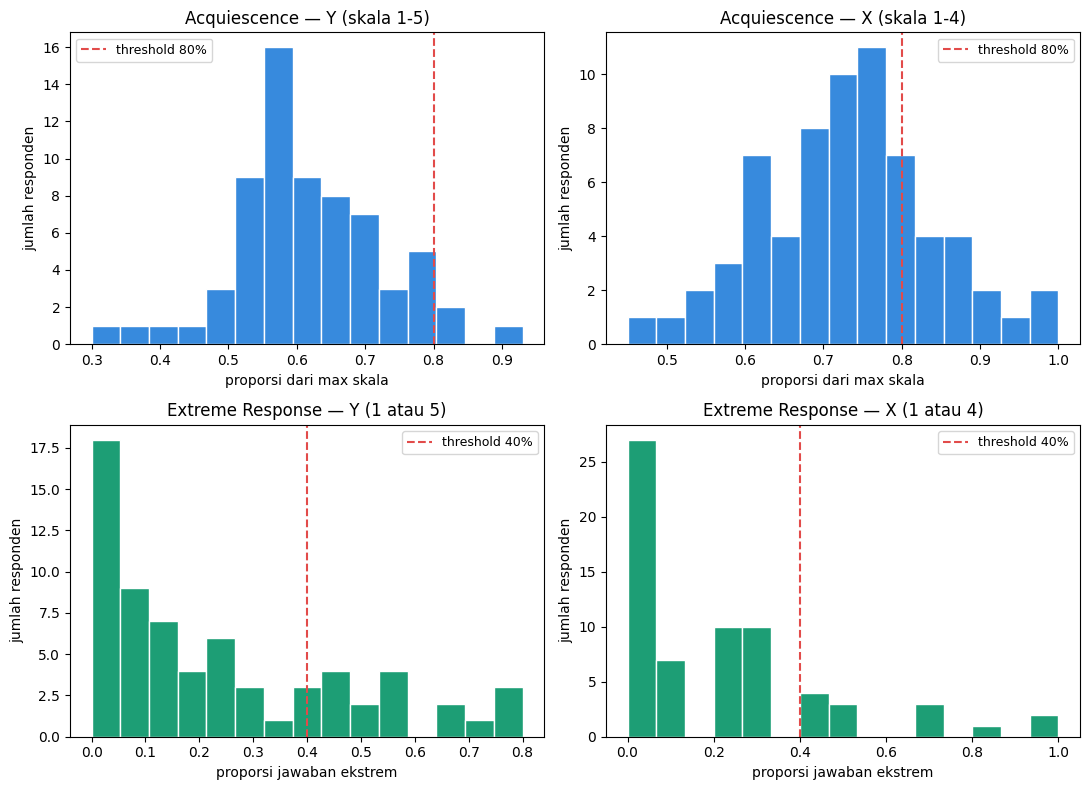

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Acquiescence Y
axes[0,0].hist(y_mean, bins=15, color="#378ADD", edgecolor="white")
axes[0,0].axvline(0.8, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 80%")
# axes[0,0].axvline(0.2, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 20%")
axes[0,0].set_title("Acquiescence — Y (skala 1-5)")
axes[0,0].set_xlabel("proporsi dari max skala")
axes[0,0].set_ylabel("jumlah responden")
axes[0,0].legend(fontsize=9)

# Acquiescence X
axes[0,1].hist(x_mean, bins=15, color="#378ADD", edgecolor="white")
axes[0,1].axvline(0.8, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 80%")
# axes[0,1].axvline(0.2, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 20%")
axes[0,1].set_title("Acquiescence — X (skala 1-4)")
axes[0,1].set_xlabel("proporsi dari max skala")
axes[0,1].set_ylabel("jumlah responden")
axes[0,1].legend(fontsize=9)

# Extreme Y
axes[1,0].hist(extreme_y, bins=15, color="#1D9E75", edgecolor="white")
axes[1,0].axvline(0.4, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 40%")
axes[1,0].set_title("Extreme Response — Y (1 atau 5)")
axes[1,0].set_xlabel("proporsi jawaban ekstrem")
axes[1,0].set_ylabel("jumlah responden")
axes[1,0].legend(fontsize=9)

# Extreme X
axes[1,1].hist(extreme_x, bins=15, color="#1D9E75", edgecolor="white")
axes[1,1].axvline(0.4, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 40%")
axes[1,1].set_title("Extreme Response — X (1 atau 4)")
axes[1,1].set_xlabel("proporsi jawaban ekstrem")
axes[1,1].set_ylabel("jumlah responden")
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Filter Data dan Export Data

In [42]:
df_final = pd.concat([df.iloc[:, 1:3], df.iloc[:, 23:33]], axis = 1)

In [43]:
auto_drop = (
    (bias_summary['total_bias'] > 2) |
    (bias_summary['straight_x_or_y'])
)

print(f"Auto drop  : {auto_drop.sum()} responden {list(df_final[auto_drop].index)}")
print(f"Retain     : {(~auto_drop & flagged).sum()} responden borderline {list(df_final[~auto_drop & flagged].index)}")
print(f"Sisa bersih: {len(df_final) - auto_drop.sum()} responden")


Auto drop  : 9 responden [5, 32, 34, 37, 43, 45, 55, 58, 61]
Retain     : 10 responden borderline [0, 20, 21, 25, 26, 51, 56, 60, 65, 66]
Sisa bersih: 58 responden


In [44]:
df_final.shape

(67, 12)

In [45]:
drop_idx = df_final[auto_drop].index

var_y = var_y.drop(index=drop_idx).reset_index(drop=True)
df_final = df_final.drop(index=drop_idx).reset_index(drop=True)

In [46]:
print(df_final.shape)
df_final.head()

(58, 12)


,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3


In [47]:
print(var_y.shape)
var_y.head()

(58, 20)


,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


In [48]:
df_final.to_csv('df.csv', index=False)
var_y.to_csv('var_y.csv', index=False)